In [1]:
import sys
#%load_ext autoreload
#%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD_lab3
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

LOG.propagate = False

In [2]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-02-24 05:05:26,393 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:b4:24:2b:64
2026-02-24 05:05:26,393 | INFO     |: Scanning for device with address: c0:81:b4:24:2b:64, service UUID: 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-02-24 05:05:36,530 | INFO     |: Found 1 device(s) advertising service 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-02-24 05:05:36,542 | INFO     |: Selecting device: 38645F53-E5BF-2155-7DF0-DBDE5B0B8B54 (name: Artemis BLE)
2026-02-24 05:05:37,854 | INFO     |: Connected to c0:81:b4:24:2b:64


In [3]:
timestamps = []
tof_sensor1_data = []
def tof_sensor1_reading_notif_handler(uuid, byte_array):
    # get data from Artemis through ble
    s = ble.bytearray_to_string(byte_array)
    # split string (e.g. "Distance(mm):100,T:1234") into key-value pairs
    s_split = dict(item.split(":") for item in s.split(","))
    # append values to arrays for plotting
    tof_sensor1_data.append(int(s_split["Distance(mm)"]))
    timestamps.append(int(s_split["T"]))

In [4]:
NUM_SAMPLES = 100      # for each expected measurement
SAMPLE_DELAY = 0.05  # seconds between requests

# clear old data
timestamps.clear()
tof_sensor1_data.clear()

In [9]:
# continuously append without clearing (fill with different measured measurement)
ble.start_notify(ble.uuid['RX_STRING'], tof_sensor1_reading_notif_handler)  # FIX: added missing start_notify
for i in range(NUM_SAMPLES):
    ble.send_command(CMD_lab3.GET_SENSOR1_DATA, "")
    time.sleep(SAMPLE_DELAY)
ble.stop_notify(ble.uuid['RX_STRING'])  # FIX: was RX_STRING
print(f"Collected {len(tof_sensor1_data)} samples") # also indicate data finishes collecting!

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x10a12bdc0> is already entered


Collected 495 samples


In [10]:
known_distances_mm = [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
d = np.array(tof_sensor1_data)
d_reshaped = d.reshape(len(known_distances_mm), NUM_SAMPLES)
means   = np.mean(d_reshaped, axis=1)
stddevs = np.std(d_reshaped,  axis=1)


Task was destroyed but it is pending!
task: <Task pending name='Task-75' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/michelleyang/repos-cornell-courses/ECE-4160-Fast-Robot/FastRobots_ble/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-76' coro=<Kernel.shell_main() running at /Users/michelleyang/repos-cornell-courses/ECE-4160-Fast-Robot/FastRobots_ble/lib/python3.13/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/michelleyang/repos-cornell-courses/ECE-4160-Fast-Robot/FastRobots_ble/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/michelleyang/repos-cornell-courses/ECE-4160-Fast-Robot/FastRobots_ble/lib/python3.13/site-packages/pygments/token.py:44: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return 'Token' + (self and '.' or '') + '.'.join(self)
Task was destroyed but it is pending!
task: <Task pending 

ValueError: cannot reshape array of size 495 into shape (10,100)

In [12]:
plt.figure(figsize=(7, 5))
plt.figure(figsize=(7, 5))
plt.errorbar(known_distances_mm, means, yerr=stddevs,
             fmt='o-', color='red', capsize=4,
             label='Mean ± 1σ (100 measurements)')
plt.plot([0, 2100], [0, 2100], 'k--', label='Ideal (measured = actual)')
plt.xlabel("Actual distance [mm]")
plt.ylabel("Measured distance [mm]")
plt.title("VL53L1X ToF Sensor — Long Mode Characterization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("tof_characterization.png", dpi=150)
plt.show()

NameError: name 'means' is not defined

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

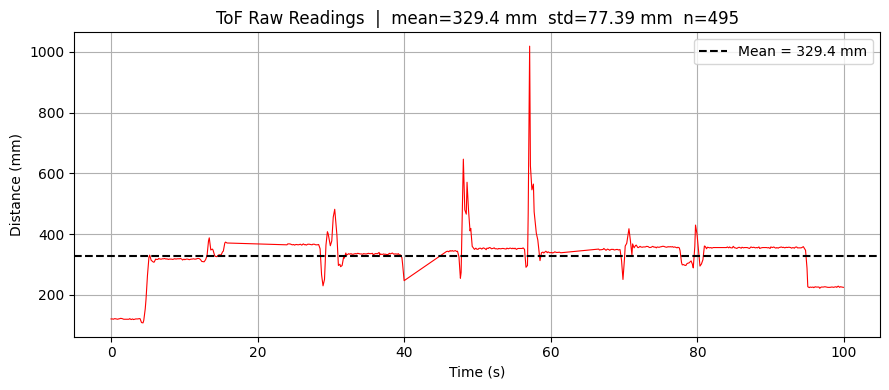

Mean:   329.4 mm
StdDev: 77.39 mm
Min:    108 mm
Max:    1019 mm


In [11]:
d = np.array(tof_sensor1_data)
t = np.array(timestamps)
t = (t - t[0]) / 1000  # convert ms to seconds, start at 0

plt.figure(figsize=(9, 4))
plt.plot(t, d, color='red', linewidth=0.8)
plt.axhline(np.mean(d), color='black', linestyle='--', label=f'Mean = {np.mean(d):.1f} mm')
plt.xlabel("Time (s)")
plt.ylabel("Distance (mm)")
plt.title(f"ToF Raw Readings  |  mean={np.mean(d):.1f} mm  std={np.std(d):.2f} mm  n={len(d)}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mean:   {np.mean(d):.1f} mm")
print(f"StdDev: {np.std(d):.2f} mm")
print(f"Min:    {np.min(d)} mm")
print(f"Max:    {np.max(d)} mm")

Segment 1 | expected=200 mm → mean=263.4 mm, std=94.08 mm, n=99
Segment 2 | expected=400 mm → mean=345.0 mm, std=34.53 mm, n=99
Segment 3 | expected=600 mm → mean=375.1 mm, std=91.85 mm, n=99
Segment 4 | expected=800 mm → mean=347.9 mm, std=26.14 mm, n=99
Segment 5 | expected=1000 mm → mean=315.7 mm, std=59.71 mm, n=99


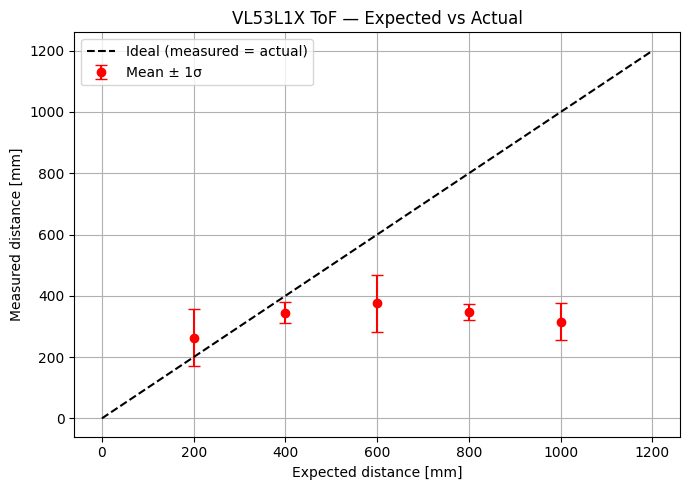

In [12]:
# Fill in the distances you actually measured at, in the order you collected them
my_known_distances = [200, 400, 600, 800, 1000]  # <-- edit these to match what you measured

n_segments = len(my_known_distances)
chunk_size = len(tof_sensor1_data) // n_segments  # e.g. 495//5 = 99

d = np.array(tof_sensor1_data)
means   = []
stddevs = []

for i, known_d in enumerate(my_known_distances):
    chunk = d[i*chunk_size : (i+1)*chunk_size]
    means.append(np.mean(chunk))
    stddevs.append(np.std(chunk))
    print(f"Segment {i+1} | expected={known_d} mm → mean={np.mean(chunk):.1f} mm, std={np.std(chunk):.2f} mm, n={len(chunk)}")

means   = np.array(means)
stddevs = np.array(stddevs)

# Plot expected vs actual
plt.figure(figsize=(7, 5))
plt.errorbar(my_known_distances, means, yerr=stddevs,
             fmt='o', color='red', capsize=4, label='Mean ± 1σ')
plt.plot([0, max(my_known_distances)+200], [0, max(my_known_distances)+200],
         'k--', label='Ideal (measured = actual)')
plt.xlabel("Expected distance [mm]")
plt.ylabel("Measured distance [mm]")
plt.title("VL53L1X ToF — Expected vs Actual")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()